In [2]:
!pip install opencv-python scikit-image scikit-learn

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from sklearn.decomposition import PCA

Saving OIP.jfif to OIP (1).jfif


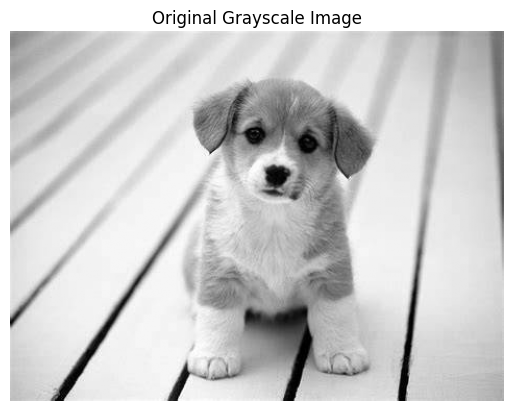

In [4]:
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

image = cv2.imread(image_path)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis('off')
plt.show()

In [5]:
glcm = graycomatrix(
    gray,
    distances=[1],
    angles=[0],
    levels=256,
    symmetric=True,
    normed=True
)
contrast = graycoprops(glcm, 'contrast')[0,0]
energy = graycoprops(glcm, 'energy')[0,0]
homogeneity = graycoprops(glcm, 'homogeneity')[0,0]
correlation = graycoprops(glcm, 'correlation')[0,0]

print("GLCM Features:")
print("Contrast:", contrast)
print("Energy:", energy)
print("Homogeneity:", homogeneity)
print("Correlation:", correlation)

GLCM Features:
Contrast: 90.2666170383825
Energy: 0.06413081764880424
Homogeneity: 0.4886504148447761
Correlation: 0.9807577986695158


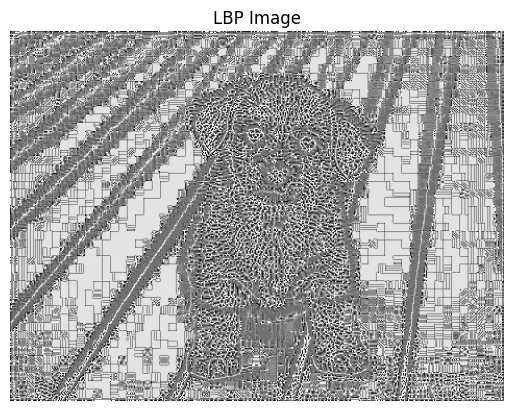

In [6]:
radius = 1
n_points = 8 * radius

lbp = local_binary_pattern(
    gray,
    n_points,
    radius,
    method='uniform'
)

plt.imshow(lbp, cmap='gray')
plt.title("LBP Image")
plt.axis('off')
plt.show()

In [7]:
n_bins = int(lbp.max() + 1)
(hist, _) = np.histogram(lbp.ravel(), bins=range(0, n_bins + 1), density=True)

print("LBP Histogram (normalized):")
print(hist)

print("\nGLCM Features:")
print(f"Contrast: {contrast}")
print(f"Energy: {energy}")
print(f"Homogeneity: {homogeneity}")
print(f"Correlation: {correlation}")

LBP Histogram (normalized):
[0.0148333  0.03622749 0.0228799  0.10205028 0.18434659 0.21702027
 0.06579901 0.05628454 0.25040708 0.05015154]

GLCM Features:
Contrast: 90.2666170383825
Energy: 0.06413081764880424
Homogeneity: 0.4886504148447761
Correlation: 0.9807577986695158
